./UPDATED_dataset_with_topics_communities_crossover.csv


Rows: 4326

=== TikTok Proportion by Lyrical Theme (label_short) ===
                               total_songs  tiktok_songs  tiktok_proportion
label_short                                                                
Hype Rap / Flex                        333            76           0.228228
Chant / Hook Pop                       116            21           0.181034
Latin Trap / Urbano                    224            39           0.174107
Romantic Reggaeton / Party             161            27           0.167702
Melodic Trap                           139            22           0.158273
Alternative / Atmospheric Pop          130            20           0.153846
Emo Rap / Melodic Hip-Hop               93            14           0.150538
Sad Pop / Breakup                      237            35           0.147679
Pop-R&B (Sensual)                      140            19           0.135714
Mainstream Pop                         288            37           0.128472
Global Trap / Hype 

/var/folders/8j/09s5dmq15nq3ccxwxgyb44zc0000gn/T/ipykernel_51044/1679386931.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


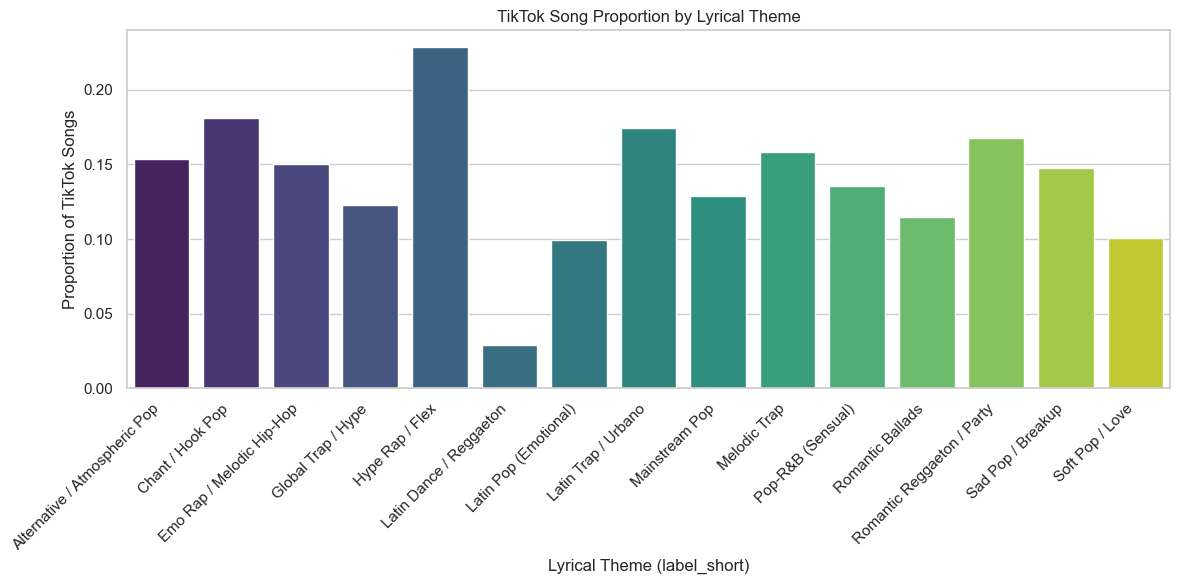

/var/folders/8j/09s5dmq15nq3ccxwxgyb44zc0000gn/T/ipykernel_51044/1679386931.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(



=== Chi-square Test: TikTok ~ label_short ===
Chi2: 53.789896356371564
p-value: 1.3953131777527208e-06


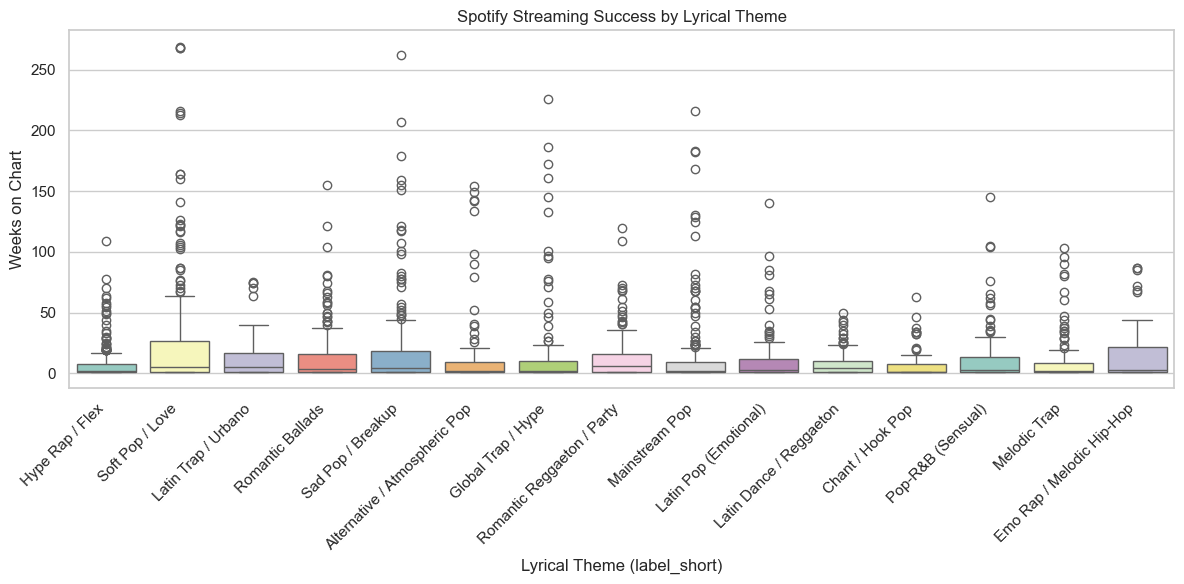


=== Kruskal-Wallis Test: Weeks on Chart ~ label_short ===
Statistic: 63.8929928789064
p-value: 2.4089460770833016e-08

=== Spotify Streaming Summary by Lyrical Theme (label_short) ===
                               median_weeks  mean_weeks  iqr_weeks  count
label_short                                                              
Romantic Reggaeton / Party              6.0   13.744361      15.00    133
Latin Trap / Urbano                     5.5   11.365169      16.00    178
Soft Pop / Love                         5.0   26.880734      25.75    218
Latin Dance / Reggaeton                 4.0    7.590361       9.00    166
Sad Pop / Breakup                       4.0   19.958333      17.25    192
Romantic Ballads                        3.5   13.150485      14.75    206
Emo Rap / Melodic Hip-Hop               3.0   14.987342      20.50     79
Latin Pop (Emotional)                   3.0    9.068376      10.75    234
Pop-R&B (Sensual)                       3.0   12.625000      12.25    120
A

In [26]:
# ===========================================
# 0. Import Libraries
# ===========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


# ===========================================
# 1. Load Your Dataset
# ===========================================
df = pd.read_csv("./UPDATED_dataset_with_topics_communities_crossover.csv")

print("Rows:", len(df))
df.head()


# ===========================================
# 2. RQ1-A: TikTok 是否集中在特定歌词主题（label_short）？
# -------------------------------------------
df["is_tiktok"] = df["source"].str.contains("tiktok", case=False, na=False)

tiktok_prop = (
    df.groupby("label_short")
      .agg(
          total_songs=("track_name", "count"),
          tiktok_songs=("is_tiktok", "sum")
      )
)

tiktok_prop["tiktok_proportion"] = (
    tiktok_prop["tiktok_songs"] / tiktok_prop["total_songs"]
)

print("\n=== TikTok Proportion by Lyrical Theme (label_short) ===")
print(tiktok_prop.sort_values("tiktok_proportion", ascending=False))


# Bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=tiktok_prop.reset_index(),
    x="label_short",
    y="tiktok_proportion",
    palette="viridis"
)
plt.title("TikTok Song Proportion by Lyrical Theme")
plt.xlabel("Lyrical Theme (label_short)")
plt.ylabel("Proportion of TikTok Songs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Chi-square test
cont_table = pd.crosstab(df["label_short"], df["is_tiktok"])
chi2, p, dof, expected = chi2_contingency(cont_table)

print("\n=== Chi-square Test: TikTok ~ label_short ===")
print("Chi2:", chi2)
print("p-value:", p)


# ===========================================
# 3. RQ1-B: Spotify Streaming Success by Lyrics Theme (label_short)
# -------------------------------------------
valid = df.dropna(subset=["weeks_on_chart", "label_short"])

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=valid,
    x="label_short",
    y="weeks_on_chart",
    palette="Set3"
)
plt.title("Spotify Streaming Success by Lyrical Theme")
plt.xlabel("Lyrical Theme (label_short)")
plt.ylabel("Weeks on Chart")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Kruskal-Wallis
groups = [
    g["weeks_on_chart"].values
    for _, g in valid.groupby("label_short")
    if len(g) > 1
]

stat, p_value = kruskal(*groups)

print("\n=== Kruskal-Wallis Test: Weeks on Chart ~ label_short ===")
print("Statistic:", stat)
print("p-value:", p_value)


# ===========================================
# 4. Summary table (for Results writing)
# -------------------------------------------
summary = (
    valid.groupby("label_short")
         .agg(
             median_weeks=("weeks_on_chart", "median"),
             mean_weeks=("weeks_on_chart", "mean"),
             iqr_weeks=("weeks_on_chart", lambda x: x.quantile(0.75) - x.quantile(0.25)),
             count=("weeks_on_chart", "count")
         )
)

print("\n=== Spotify Streaming Summary by Lyrical Theme (label_short) ===")
print(summary.sort_values("median_weeks", ascending=False))


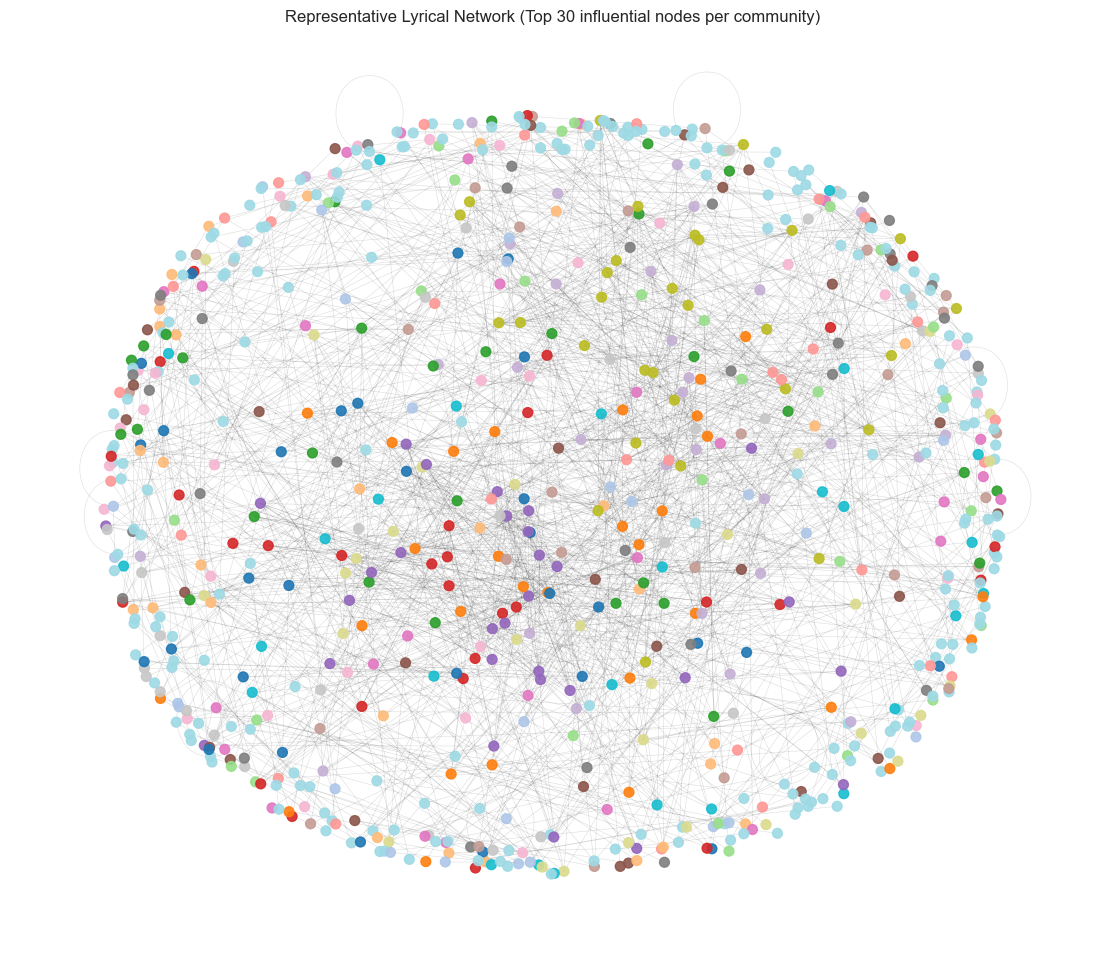

In [43]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Load files
edges = pd.read_csv("edges_weighted.csv")
nodes = pd.read_csv("nodes_with_communities.csv")

# --- Step 1: pick representative nodes ---
top_nodes = []

for c, group in nodes.groupby("community"):
    # pick top central nodes
    top_group = group.nlargest(30, "eigenvector_centrality")
    top_nodes.append(top_group)

nodes_rep = pd.concat(top_nodes)
rep_ids = set(nodes_rep["node_id"])

# subset edges
edges_rep = edges[
    edges["source_idx"].isin(rep_ids) &
    edges["target_idx"].isin(rep_ids)
]

# build graph
G = nx.from_pandas_edgelist(edges_rep, "source_idx", "target_idx")

# colors
communities = sorted(nodes_rep["community"].unique())
color_map = plt.cm.tab20(range(len(communities)))
comm_color = {c: color_map[i] for i, c in enumerate(communities)}

# node colors
nodes_rep = nodes_rep.set_index("node_id")
node_colors = [comm_color[nodes_rep.loc[n, "community"]] for n in G.nodes()]

# layout
pos = nx.spring_layout(G, seed=42, k=0.9, iterations=80)

# plot
plt.figure(figsize=(14, 12))
nx.draw_networkx_nodes(G, pos, node_size=50, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.4)

plt.axis("off")
plt.title("Representative Lyrical Network (Top 30 influential nodes per community)")

plt.show()


In [34]:
!pip install fa2l


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.7 MB/s eta 0:00:00
  Created wheel for fa2l: filename=fa2l-0.2-py3-none-any.whl size=8847 sha256=37741edc72be5724bd437823bbaa1c9ddc8b754791aa9878f871a79e781b4825
  Stored in directory: /Users/blagenjeee/Library/Caches/pip/wheels/5e/75/85/8667f28ba52bd06af49ba229981cdbbbb57dec7ff6518a6285
Successfully built fa2l
  Attempting uninstall: networkx
    Found existing installation: networkx 3.3
    Uninstalling networkx-3.3:
      Successfully uninstalled networkx-3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.24.0 requires networkx>=2.8, but you have networkx 1.11 which is incompatible.
torch 2.9.0 requires networkx>=2.5.1, but you have networkx 1.11 which is incompatible.


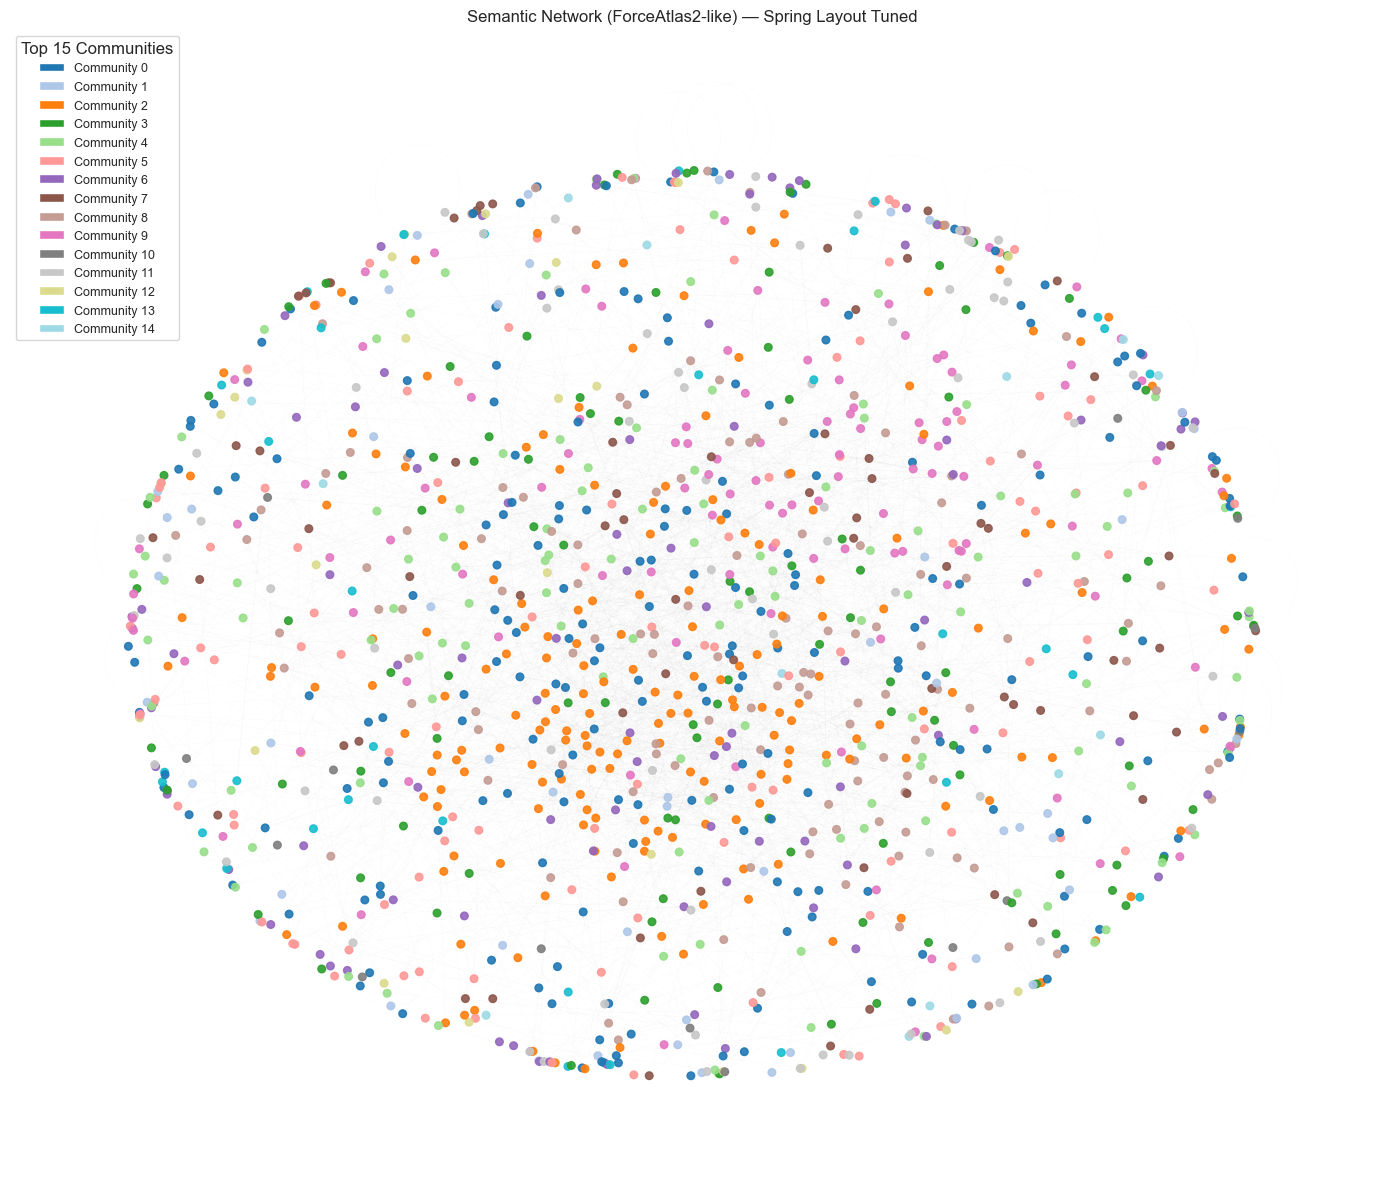

In [41]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# ----------------------------
# Load your data
# ----------------------------
edges = pd.read_csv("./edges_weighted.csv")
nodes = pd.read_csv("./nodes_with_communities.csv")

# ----------------------------
# Select Top 15 communities
# ----------------------------
top15 = nodes["community"].value_counts().nlargest(15).index
nodes_top = nodes[nodes["community"].isin(top15)].copy()
node_ids = set(nodes_top["node_id"])

# Apply threshold
THRESH = 0.75
edges_top = edges[
    (edges["weight"] >= THRESH) &
    (edges["source_idx"].isin(node_ids)) &
    (edges["target_idx"].isin(node_ids))
]

# ----------------------------
# Build Graph
# ----------------------------
G = nx.from_pandas_edgelist(
    edges_top,
    source="source_idx",
    target="target_idx",
    edge_attr="weight"
)

nodes_top = nodes_top.set_index("node_id")

# ----------------------------
# Assign colors
# ----------------------------
colors = plt.cm.tab20(np.linspace(0, 1, 15))
community_color = {c: colors[i] for i, c in enumerate(top15)}
node_colors = [community_color[nodes_top.loc[n, "community"]] for n in G.nodes()]

# ----------------------------
# ForceAtlas2-like spring layout
# ----------------------------
pos = nx.spring_layout(
    G,
    seed=42,
    k=1.8,                    # ↑ 更大的 k = 更分散 (FA2 的 scalingRatio)
    iterations=400,           # ↑ 迭代越多越像 FA2
    weight="weight"           # ↑ edge weight = FA2 edge attraction
)

# ----------------------------
# Draw graph
# ----------------------------
plt.figure(figsize=(14, 12))

nx.draw_networkx_nodes(
    G, pos,
    node_size=30,
    node_color=node_colors,
    alpha=0.90
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    width=0.25,
    alpha=0.05
)

# Legend
legend_elements = [
    Patch(facecolor=community_color[c], label=f"Community {c}") 
    for c in top15
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=9,
    title="Top 15 Communities"
)

plt.title("Semantic Network (ForceAtlas2-like) — Spring Layout Tuned")
plt.axis("off")
plt.tight_layout()
plt.show()


Original edges: 6513
Edges after threshold: 3585
Nodes kept: 1519


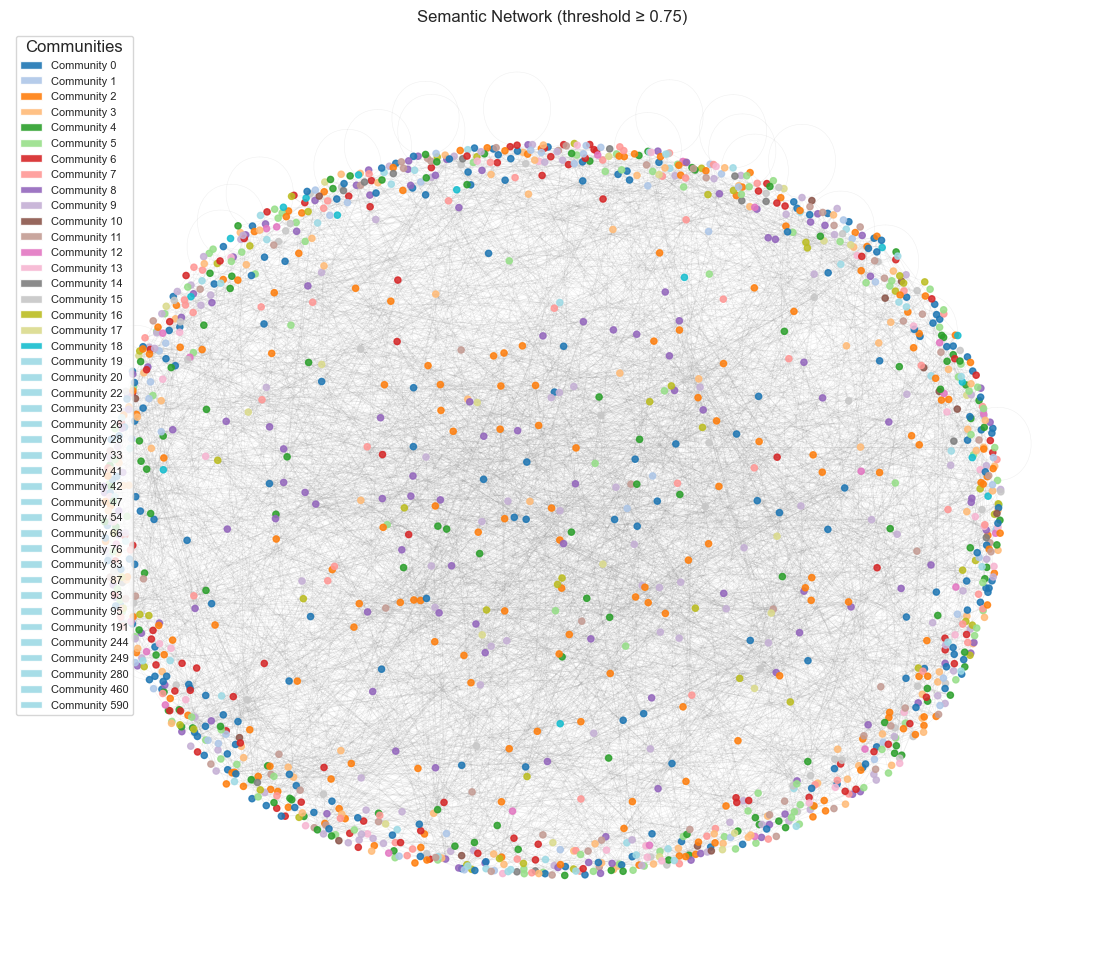

In [30]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ----------------------------
# Load data
# ----------------------------
edges = pd.read_csv("./edges_weighted.csv")
nodes = pd.read_csv("./nodes_with_communities.csv")

print("Original edges:", len(edges))

# ----------------------------
# 1. Filter edges with threshold >= 0.75
# ----------------------------
THRESH = 0.75
edges_f = edges[edges["weight"] >= THRESH].copy()

print("Edges after threshold:", len(edges_f))

# ----------------------------
# 2. Build graph
# ----------------------------
G = nx.from_pandas_edgelist(
    edges_f,
    source="source_idx",
    target="target_idx",
    edge_attr="weight"
)

# Keep only nodes that appear in edges
valid_nodes = list(G.nodes())
nodes_f = nodes[nodes["node_id"].isin(valid_nodes)].copy()

print("Nodes kept:", len(nodes_f))

# ----------------------------
# 3. Assign colors from community
# ----------------------------
communities = sorted(nodes_f["community"].unique())
color_map = plt.cm.tab20(range(len(communities)))
comm_color = {c: color_map[i] for i, c in enumerate(communities)}

nodes_f = nodes_f.set_index("node_id")

node_colors = [comm_color[nodes_f.loc[n, "community"]] for n in G.nodes()]

# ----------------------------
# 4. Layout (spring)
# ----------------------------
pos = nx.spring_layout(G, seed=42, k=1.0, iterations=80)

# ----------------------------
# 5. Draw graph
# ----------------------------
plt.figure(figsize=(14, 12))

nx.draw_networkx_nodes(
    G, pos,
    node_size=20,
    node_color=node_colors,
    alpha=0.85
)

nx.draw_networkx_edges(
    G, pos,
    alpha=0.12,
    width=0.4,
    edge_color="gray"
)

# ----------------------------
# 6. Legend
# ----------------------------
legend_elements = [
    Patch(facecolor=comm_color[c], label=f"Community {c}", alpha=0.9)
    for c in communities
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=8,
    title="Communities"
)

plt.title(f"Semantic Network (threshold ≥ {THRESH})")
plt.axis("off")
plt.show()


Top 15 communities retained: 2346 nodes, 3196 edges


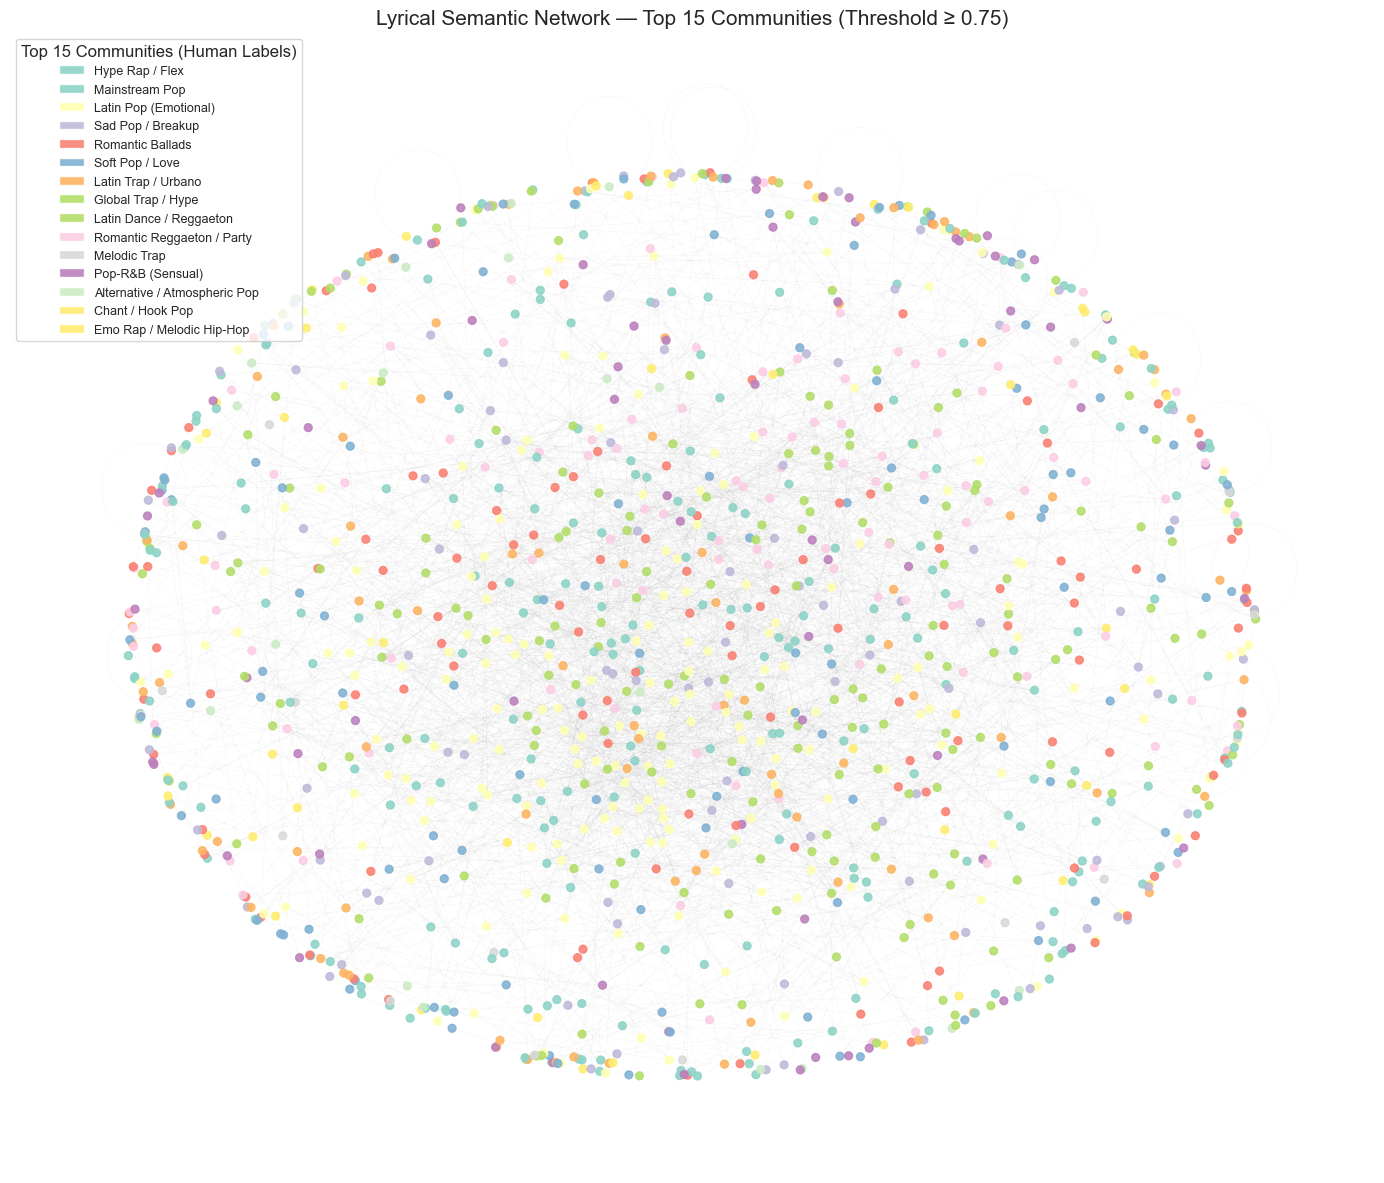

In [51]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# ----------------------------
# Load data (update path to your actual files)
# ----------------------------
edges = pd.read_csv("./edges_weighted.csv")
nodes = pd.read_csv("./nodes_with_communities.csv")
crossover = pd.read_csv("./UPDATED_dataset_with_topics_communities_crossover.csv")

# ----------------------------
# 1. Community → label_short mapping
# ----------------------------
label_map = (
    crossover.groupby("community")["label_short_simplified"]
    .agg(lambda s: s.value_counts().idxmax())
    .to_dict()
)

# ----------------------------
# 2. Select Top 15 communities
# ----------------------------
top15 = nodes["community"].value_counts().nlargest(15).index
nodes_top = nodes[nodes["community"].isin(top15)].copy()
node_ids_top = set(nodes_top["node_id"])

# ----------------------------
# 3. Apply threshold (NEW!)
# ----------------------------
THRESH = 0.75
edges_top = edges[
    (edges["source_idx"].isin(node_ids_top)) &
    (edges["target_idx"].isin(node_ids_top)) &
    (edges["weight"] >= THRESH)
].copy()

print(f"Top 15 communities retained: {len(nodes_top)} nodes, {len(edges_top)} edges")

# ----------------------------
# 4. Build Graph
# ----------------------------
G = nx.from_pandas_edgelist(
    edges_top,
    "source_idx",
    "target_idx",
    edge_attr="weight"
)

nodes_top = nodes_top.set_index("node_id")

# ----------------------------
# 5. Color mapping
# ----------------------------
color_map = plt.cm.Set3(np.linspace(0, 1, len(top15)))
community_map = {c: i for i, c in enumerate(top15)}

node_colors = [
    color_map[community_map[nodes_top.loc[n, "community"]]]
    for n in G.nodes()
]

# ----------------------------
# 6. FA2-like spring layout (tuned)
# ----------------------------
pos = nx.spring_layout(
    G,
    seed=42,
    k=1.6,              # ↑ 更大的 k 让 graph 更分散 → 更像 ForceAtlas2
    weight="weight",    # ↑ 强边更吸引
    iterations=300       # ↑ 更多迭代 → 收敛更稳定
)

# ----------------------------
# 7. Draw network
# ----------------------------
plt.figure(figsize=(14, 12))

nx.draw_networkx_nodes(
    G, pos,
    node_size=32,
    node_color=node_colors,
    alpha=0.88
)

nx.draw_networkx_edges(
    G, pos,
    width=0.35,
    alpha=0.08,
    edge_color="gray"
)

# ----------------------------
# 8. Legend (using label_short_simplified)
# ----------------------------
legend_elements = [
    Patch(
        facecolor=color_map[i],
        label=label_map.get(c, f"Community {c}"),
        alpha=0.9
    )
    for i, c in enumerate(top15)
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=9,
    title="Top 15 Communities (Human Labels)"
)

# ----------------------------
# 9. Final display
# ----------------------------
plt.title(f"Lyrical Semantic Network — Top 15 Communities (Threshold ≥ {THRESH})", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
GEPHIIII

In [55]:
import pandas as pd
import networkx as nx

# ----------------------------
# 1. Load data
# ----------------------------
edges = pd.read_csv("./edges_weighted.csv")
nodes = pd.read_csv("./nodes_with_communities.csv")
crossover = pd.read_csv("./UPDATED_dataset_with_topics_communities_crossover.csv")

# ----------------------------
# 2. Build mapping: community → label_short_simplified
# ----------------------------
label_map = (
    crossover.groupby("community")["label_short_simplified"]
    .agg(lambda s: s.value_counts().idxmax())
    .to_dict()
)

# ----------------------------
# 3. Select Top 15 communities
# ----------------------------
top15 = nodes["community"].value_counts().nlargest(15).index.tolist()

nodes_top = nodes[nodes["community"].isin(top15)].copy()
node_ids_top = set(nodes_top["node_id"])

# ----------------------------
# 4. Apply threshold ≥ 0.75
# ----------------------------
THRESH = 0.75
edges_top = edges[
    (edges["source_idx"].isin(node_ids_top)) &
    (edges["target_idx"].isin(node_ids_top)) &
    (edges["weight"] >= THRESH)
]

print(f"Nodes kept: {len(nodes_top)}")
print(f"Edges kept: {len(edges_top)}")

# ----------------------------
# 5. Build Graph (NetworkX)
# ----------------------------
G = nx.Graph()

# Add nodes with attributes (Gephi will read these!)
for _, row in nodes_top.iterrows():
    G.add_node(
        row["node_id"],
        community=int(row["community"]),
        label=label_map.get(row["community"], f"Comm {row['community']}"),
        track_name=row.get("track_name", ""),
        artist=row.get("artist_name", "")
    )

# Add edges
for _, row in edges_top.iterrows():
    G.add_edge(
        int(row["source_idx"]),
        int(row["target_idx"]),
        weight=float(row["weight"])
    )

# ----------------------------
# 6. Export to .gexf
# ----------------------------
output_path = "semantic_network_top15_th75.gexf"
nx.write_gexf(G, output_path)

print("GEXF successfully saved to:", output_path)


Nodes kept: 2346
Edges kept: 3196
GEXF successfully saved to: semantic_network_top15_th75.gexf
